## Puprose of Notebook ## 

Matching DES SNIa to host galaxies listed as part of the DR1 DESI data release. 

## Content of DESI Galaxy Metadata Files ##



Please note that in this notebook there are two .fits files:

- `desi_galaxy_metadata_dark.fits`
-  `desi_galaxy_metadata.fits`

These files were filtered out from the main raw data files found at: 

https://data.desi.lbl.gov/public/dr1/

What Each Collumn of raw .fits files means: https://fastspecfit.readthedocs.io/en/stable/fastspec.html


The filtering consisted of getting out only galaxy related information from agregate data 
that was part of both the dark and bright iron fits survey.

The original desi data contained Qasuars Stars and Galaxies. The filtering work done here 
involved only looking at the Galaxy data and taking out the following parameters:

['TARGETID', 'RA', 'DEC', 'DESI_TARGET', 'SPECTYPE', 'Z', 'ZWARN']

For the work on how this was done please refer to:

`DES5YR_DESI_explore.ipynb`

## More detials on how data was sourced: ##

The reference for the following description is the following paper: https://arxiv.org/abs/2503.14745

Within each survey, objects are observed in one of three possible programs, depending on the acceptable lunar phase and on-sky observing conditions:

- **bright** — Observed during bright time (e.g., near full Moon)
- **dark** — Observed during dark time (e.g., new Moon)
- **backup** — Observed when conditions are not ideal for primary programs

I chose to focus only on the bright and dark survey. This is where the two data files end up coming from. Backup data set was ignored b/c it contained secondary and tertiary targets.

### Spectroscopic Production in DESI DR1 - IRON

Spectroscopic production: full, systematic data processing pipeline run on a defined set of raw DESI spectroscopic exposures. Each production results in calibrated spectra, redshifts, and other derived quantities that are released for public use and scientific analysis.

The primary spectroscopic production for DR1 is called **Iron**, named after the Iron Mountain in Utah. This production includes data from the first 13 months of the DESI main survey, as well as a uniform reprocessing of the Science Validation (SV) data that was previously part of the Early Data Release (EDR). 

In addition to Iron, DR1 also includes a supplemental production called **Guadalupe** (named after the Guadalupe Mountains in Texas), which contains data from just the first two months of the main survey. Although Guadalupe was used in early DESI analyses, it was processed using the same calibration and software as the older Fuji production used in the EDR. As such, Iron should be preferred over Guadalupe for any current or future work, due to its broader coverage and superior data processing quality.

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table, hstack, vstack  # <-- added vstack here
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

### Defining a function that converts RA/DEC from degrees to Mollweide-friendly radians ###

This is done because when we plot a molleweide projection later the function responsible for it only takes in radians as arguments.

Note: this is pretty counter-intuitive because the function is after all: displaying our output in degrees 🤣.


In [2]:
def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

### Making a Plot of DES5YR SNIa host galaxy locations vs. the bright and dark galaxies from DESI ###

Turns out that some of the SNIa that were part of the DES5YR data release were missing their host galaxy coordiantes. 
So what is plotted here is only the SNIa Host Galaxy coordiantes that existed. It is also worth it to note that in this case these were only the SNIa
that were part of the DES data release.

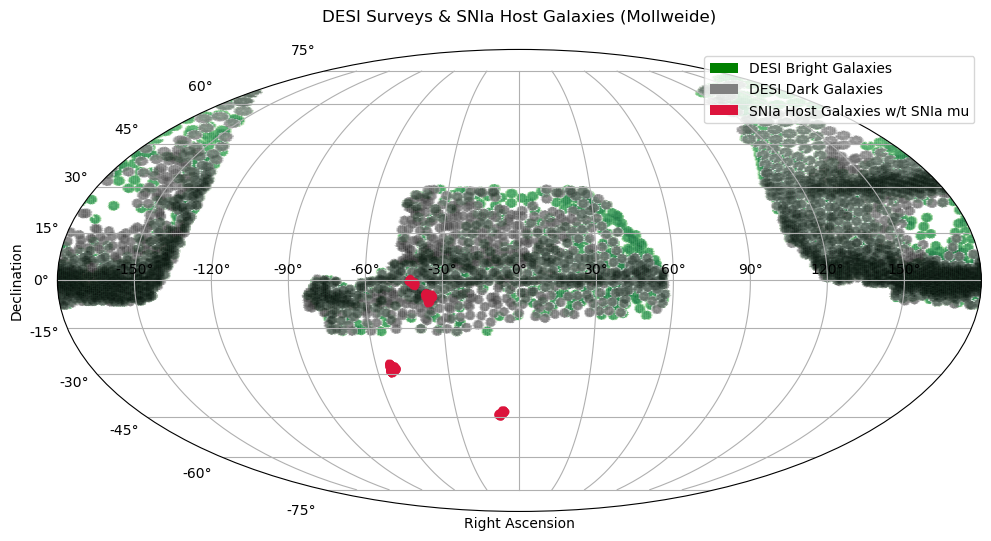

In [3]:
# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load SNIa Metadata CSV ===
sn_df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid host coordinates
valid_hosts = (sn_df['HOST_RA'] != -999) & (sn_df['HOST_DEC'] != -999)
host_ra = sn_df.loc[valid_hosts, 'HOST_RA'].values
host_dec = sn_df.loc[valid_hosts, 'HOST_DEC'].values
ra_host, dec_host = prepare_coords(host_ra, host_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts (scatter instead of density)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')

# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='crimson', label='SNIa Host Galaxies w/t SNIa mu', alpha=1)
]
ax.legend(handles=legend_elements, loc='upper right')

# Plot settings
ax.set_title('DESI Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

### Plotting A Superposition of SNIa that have Host Galaxy Information and those that Don't ###

We first start by creating and saving a .csv of all the entries where the host galaxy locations were missing. 
Note: just because the location is missing, doesn't mean that the host galaxy does not exist for the SNIa. 
It's just been forgotten/or maybe there was an error in getting this hostgalaxy information out there. 

Please note: the following output `snia_with_missing_host_coords.csv` will be in the same format as 
`DES-SN5YR_HD+MetaData.csv` retaining all the collumns but only prserving the rows with data that is associated with missing host galaxy information.

Point of interest: None of the SNIa that were part of `DES-SN5YR_HD+MetaData.csv` Hubble diagram data had the locations of the SNIa in RA and DEC. So for those that were missing that data, we ended up having to go to the `0_DATA` file and parse the .fits files. 

In [14]:
# Load the metadata CSV
df = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter for invalid host galaxy coordinates (i.e., -999)
bad_host_mask = (df['HOST_RA'] == -999) | (df['HOST_DEC'] == -999)
bad_hosts = df[bad_host_mask]

# Save to a new CSV
bad_hosts.to_csv("DES5YR_DESI_data/snia_with_missing_host_coords.csv", index=False)

In this instance the SNIa that have host galaxy coordiantes associated with them will be in red.

The SNIa that don't have host galaxy coordiantes associated with them will be in yellow. Note: that for these coordiantes: we will only use the SNIa coordiantes b/c the host galaxy coordinates are missing. 

### The Search for Missing SNIa coordiantes begins. NOTE: this is not a search for host Galaxy Coordiantes ###

This leads us to an interesting issue: you see the SNIa coordiantes themselves are missing from these .csv files. So if host coordiantes are missing. We have to find them elsewhere.

So we have to go on the hunt. The first suspicous place is of course: the fits files.


In [53]:
# Path to the FITS file
fits_path = "/global/homes/m/myc21/first_paper/DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"

# Read in the binary table from HDU 1
fits_table = Table.read(fits_path, hdu=1)

# Print summary information
print("\n=== Astropy Table Info ===")
print(f"Number of rows (i.e. number of SNIa): {len(fits_table)}")
print("Column names:")
print(fits_table.colnames)

## Commented out because it was taking up a lot of space. But could uncomment for 
## future reference.
# # Print the first row
# print("\nFirst Row:")
# print(fits_table[0])


=== Astropy Table Info ===
Number of rows (i.e. number of SNIa): 342
Column names:
['SUBSURVEY', 'SNID', 'IAUC', 'FAKE', 'MASK_FLUXCOR_SNANA', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'REDSHIFT_QUALITYFLAG', 'MASK_REDSHIFT_SOURCE', 'VPEC', 'VPEC_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_MAG_a', 'HOSTGAL_MAG_b', 'HOSTGAL_MAG_c', 'HOSTGAL_MAG_d', 'HOSTGAL_MAG_e', 'HOSTGAL_MAG_f', 'HOSTGAL_MAG_g', '

<span style="color:darkgreen; font-size:110%;"><u>Well it looks like we have the RA and DEC for Each Individual SNIa. Note: we also have a HOSTGAL_RA and HOSTGAL_DEC.</u></span>

<span style="color:darkgreen; font-size:110%;"><u>This tells us we are in the right place. Now lets see if we can get ourselves a nice match on the RA/DEC of our SNIa.</u></span>

Note: the missing data is split across the FOUNDATION and LOWZ data sets. 

In [60]:
# === Load LOWZ ===
lowz_path = "DES-SN5YR-1.2/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz"
lowz_table = Table.read(lowz_path, hdu=1).to_pandas()
if lowz_table['SNID'].dtype == object and isinstance(lowz_table['SNID'].iloc[0], bytes):
    lowz_table['SNID'] = lowz_table['SNID'].str.decode('utf-8').str.strip()

# === Load FOUNDATION ===
found_path = "DES-SN5YR-1.2/0_DATA/DES-SN5YR_Foundation/DES-SN5YR_Foundation_HEAD.FITS.gz"
found_table = Table.read(found_path, hdu=1).to_pandas()
if found_table['SNID'].dtype == object and isinstance(found_table['SNID'].iloc[0], bytes):
    found_table['SNID'] = found_table['SNID'].str.decode('utf-8').str.strip()

# === Load Metadata CSV ===
csv_path = "DES5YR_DESI_data/snia_with_missing_host_coords.csv"
meta_df = pd.read_csv(csv_path)
meta_df.rename(columns={"CID": "SNID"}, inplace=True)

# === Merge with LOWZ ===
merged_df = pd.merge(meta_df, lowz_table[['SNID', 'RA', 'DEC']], on='SNID', how='left')

# === Now try to fill missing RA/DEC using FOUNDATION ===
found_coords = found_table[['SNID', 'RA', 'DEC']].copy()
found_coords.rename(columns={'RA': 'RA_FND', 'DEC': 'DEC_FND'}, inplace=True)

# Join foundation coordinates
merged_df = pd.merge(merged_df, found_coords, on='SNID', how='left')

# === Final stitch: prefer RA from LOWZ, fallback to FOUNDATION ===
## fillna fills in the collumn with the argument if the collumn entry 
## is n/a.
merged_df['RA'] = merged_df['RA'].fillna(merged_df['RA_FND'])
merged_df['DEC'] = merged_df['DEC'].fillna(merged_df['DEC_FND'])

# Drop the extra columns
merged_df.drop(columns=['RA_FND', 'DEC_FND'], inplace=True)

# === Save it clean ===
merged_df.to_csv("DES5YR_DESI_data/SNIa_no_hostC_yes_SNIaC_LowZ_FOUNDATION.csv", index=False)

### Making a Plot that Compares the locations of all SNIa that have the Distance Modulus (Mu) Precalculated  ###

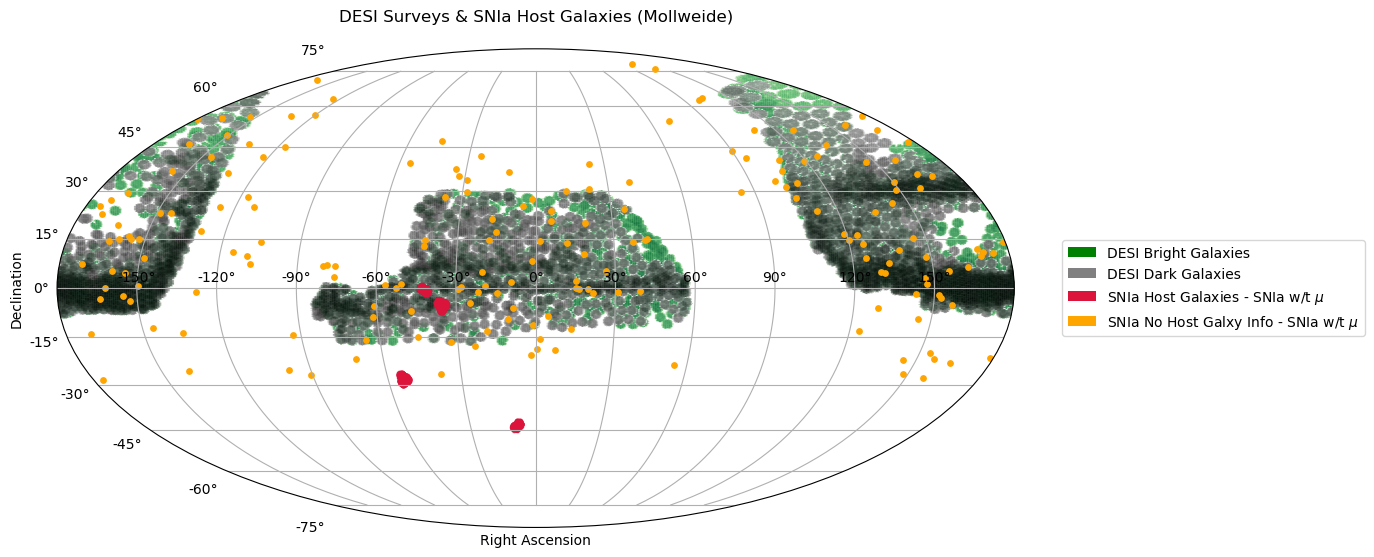

In [62]:
# === Load SNIa Partial Match CSV ===

## NOTE: some of these preparation steps are not necessary but were retained nonetheless because
partial_df = pd.read_csv("DES5YR_DESI_data/SNIa_no_hostC_yes_SNIaC_LowZ_FOUNDATION.csv")
valid_partial = partial_df['RA'].notna() & partial_df['DEC'].notna()
partial_ra = partial_df.loc[valid_partial, 'RA'].values
partial_dec = partial_df.loc[valid_partial, 'DEC'].values
x_partial, y_partial = prepare_coords(partial_ra, partial_dec)

# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()
x_host, y_host = ra_host.flatten(), dec_host.flatten()

# DESI Bright (density)
ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
          mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
          mincnt=1, linewidths=0, norm=LogNorm())

# SNIa Hosts with mu (scatter)
ax.scatter(x_host, y_host, s=10, color='crimson', alpha=0.6, label='SNIa Host Galaxies w/t SNIa mu')

# SNIa from match CSV (scatter, fixed orange color)
ax.scatter(x_partial, y_partial, s=15, color='orange', alpha=1, label='SNIa Partial Matches')

# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='crimson', label='SNIa Host Galaxies - SNIa w/t $\mu$', alpha=1),
    Patch(facecolor='orange', label='SNIa No Host Galxy Info - SNIa w/t $\mu$ ', alpha=1)
]

# External legend
ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.,
    frameon=True
)

# Plot settings
ax.set_title('DESI Surveys & SNIa Host Galaxies (Mollweide)', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.tight_layout()
plt.show()

## Matching Step ##

In [73]:
# === Step 1: Load DES 5YR SN Host Galaxy Data ===
des_sn_hostgal = pd.read_csv(
    "DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv"
)

# Filter for valid coordinates
## The purpose of these lines is to make sure to filter out the -999 vlaues in 
## the DES-SN5YR_HD+MetaData.csv. For some reason just sayin != -999 ends up 
## throwing an error.
sn_valid_mask = (
    (des_sn_hostgal["HOST_DEC"] > -90) & (des_sn_hostgal["HOST_DEC"] < 90) &
    (des_sn_hostgal["HOST_RA"] >= 0) & (des_sn_hostgal["HOST_RA"] < 360)
)

des_sn_valid = des_sn_hostgal[sn_valid_mask]

# Create SkyCoord for SN hosts
sn_coords = SkyCoord(
    ra=des_sn_valid["HOST_RA"].values * u.deg,
    dec=des_sn_valid["HOST_DEC"].values * u.deg
)

# === Step 2: Load DESI Galaxy Metadata (Dark + Bright) ===
fits_paths = [
    "DES5YR_DESI_data/desi_galaxy_metadata_dark.fits",
    "DES5YR_DESI_data/desi_galaxy_metadata.fits"
]

desi_tables = [Table.read(path, hdu=1) for path in fits_paths]

# Combine dark + bright into one table
desi_data = vstack(desi_tables, join_type='exact')

# Create SkyCoord for DESI galaxies
desi_coords = SkyCoord(
    ra=desi_data["RA"] * u.deg,
    dec=desi_data["DEC"] * u.deg
)

# === Step 3: Match SN hosts to DESI galaxies ===
## for the coordiantes in sn_coords, find the closest object in `desi coords`
## For each SNIa idx[i] tells us which row in th desi_coords has the closest match.
## sep2d is the angluar separation on the sky of the planets and stuff. 
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Define a mask that Keep matches within 1 arcsecond
## Note: this is a boolean separataor. 
max_sep = 1 * u.arcsec
match_mask = sep2d < max_sep

# === Step 4: Extract matched rows ===
## This takes the DataFrame of valid SNIa that have host info (des_sn_valid) and filters
## it down to only the rows where match_mask is True.
## Table.from_pandas converts the pandas data frame to an astropy TABLE in order to
## take advantage of the Table.hstack feature.

## For matched_desi. First applies the same match_mask filtering to the idx array.
## Now you have only the DESI row indices for SNe that passed the 1 arcsecond cutoff.

## NOTE: desi_data is already in astropy Table format from above.

matched_sn = Table.from_pandas(des_sn_valid[match_mask])
matched_desi = desi_data[idx[match_mask]]

# Add angular separation (arcsec) collumn
matched_sn["ANGSEP_ARCSEC"] = sep2d[match_mask].arcsec

# Join matched tables
## This works mostly b/c idx was used ot make the two Tables lined up perfectly.
## So we can just horizontally stack them next to each other.
matched = hstack([matched_sn, matched_desi])

# === Step 5: Save outputs ===
matched.write("DES5YR_DESI_data/desi_matched_sn.csv", format="csv", overwrite=True)

print(f"✅ Matched {len(matched)} SN-host pairs within 1 arcsec.")

✅ Matched 112 SN-host pairs within 1 arcsec.


### Redshift Match ###